In [1]:
!pip install pandas matplotlib seaborn numpy

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

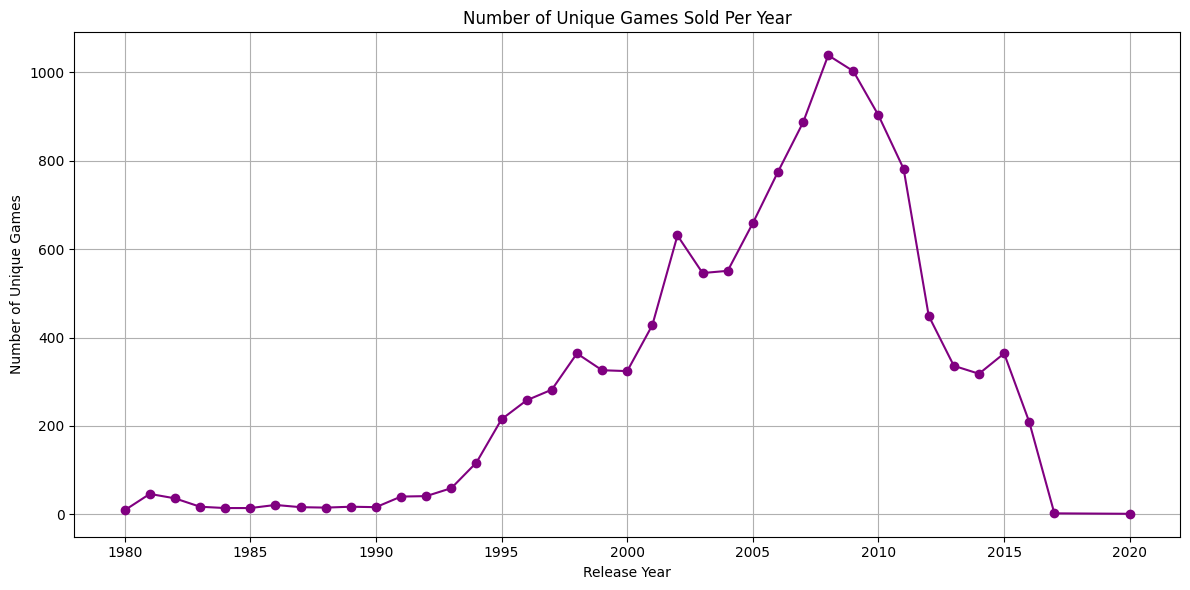

In [3]:
# Linha do tempo de numero de diferentes jogos vendidos ao longo dos anos
# Essa visualizacao foi usada mais para mapear uma zona com mais jogos para tornar a
# ultima visualizacao mais interessante
df = pd.read_csv('datasetCompVis.csv')
# df = df[(df['Year'] >= 2000) & (df['Year'] <= 2015)]
num_games_by_year = df.groupby('Year')['Name'].nunique()

plt.figure(figsize=(12, 6))
num_games_by_year.plot(kind='line', marker='o', color='purple')
plt.title('Number of Unique Games Sold Per Year')
plt.xlabel('Release Year')
plt.ylabel('Number of Unique Games')
plt.grid(True)
plt.tight_layout()
plt.show()

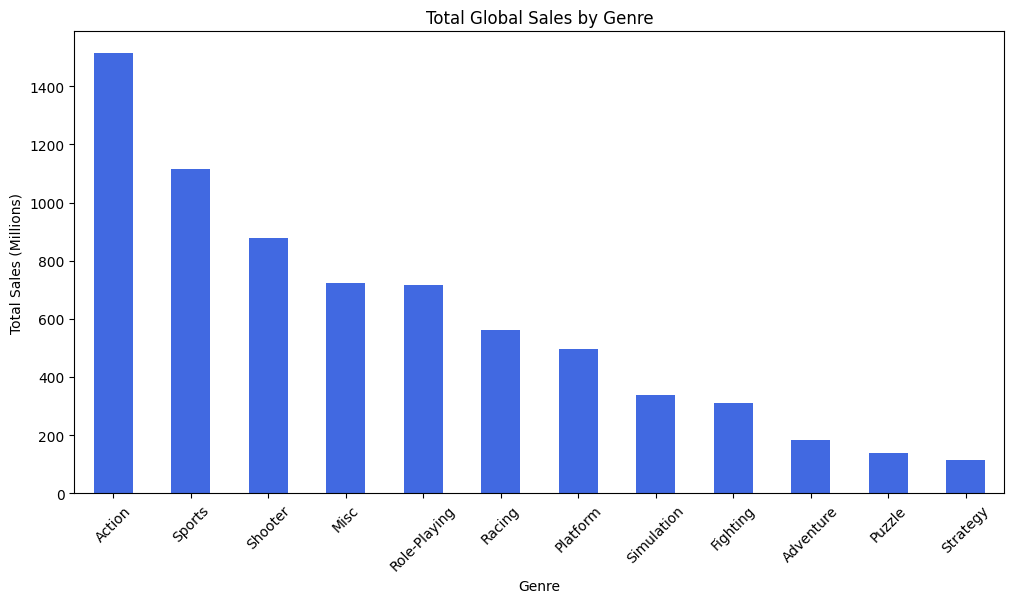

In [4]:

#Pegar os generos mais vendidos entre 2000 e 2015

df = pd.read_csv('datasetCompVis.csv')
df = df[(df['Year'] >= 2000) & (df['Year'] <= 2015)]
genres = df.groupby('Genre')['Global_Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
genres.plot(kind='bar', color='royalblue')
plt.title('Total Global Sales by Genre')
plt.xlabel('Genre')
plt.ylabel('Total Sales (Millions)')
plt.xticks(rotation=45)

plt.show()

### Years Sorted by Number of Games Released

Let's see which years had the most game releases.

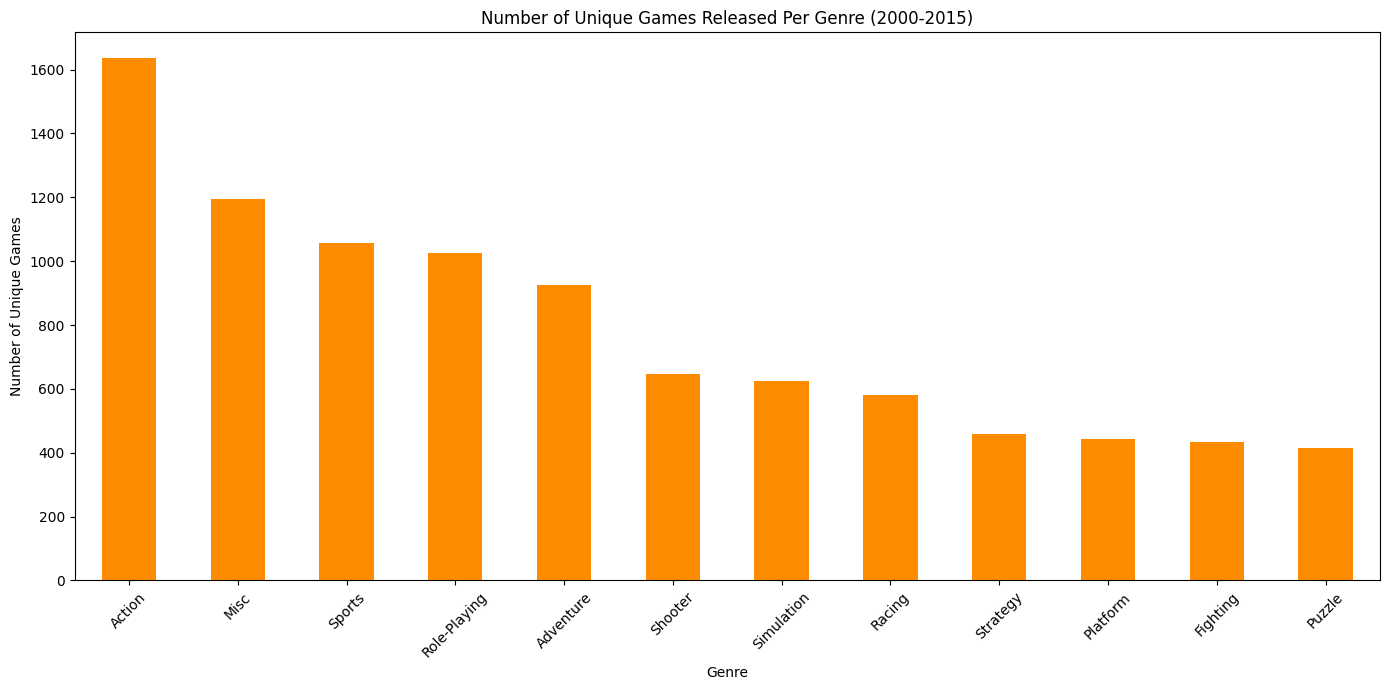

In [5]:
# Filter the DataFrame for games released between 2000 and 2015
df_2005_2011 = df[(df['Year'] >= 2000) & (df['Year'] <= 2015)]

# Group by Genre and count the number of unique game names in this period
games_per_genre_2005_2011 = df_2005_2011.groupby('Genre')['Name'].nunique().sort_values(ascending=False)

plt.figure(figsize=(14, 7))
games_per_genre_2005_2011.plot(kind='bar', color='darkorange')
plt.title('Number of Unique Games Released Per Genre (2000-2015)')
plt.xlabel('Genre')
plt.ylabel('Number of Unique Games')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

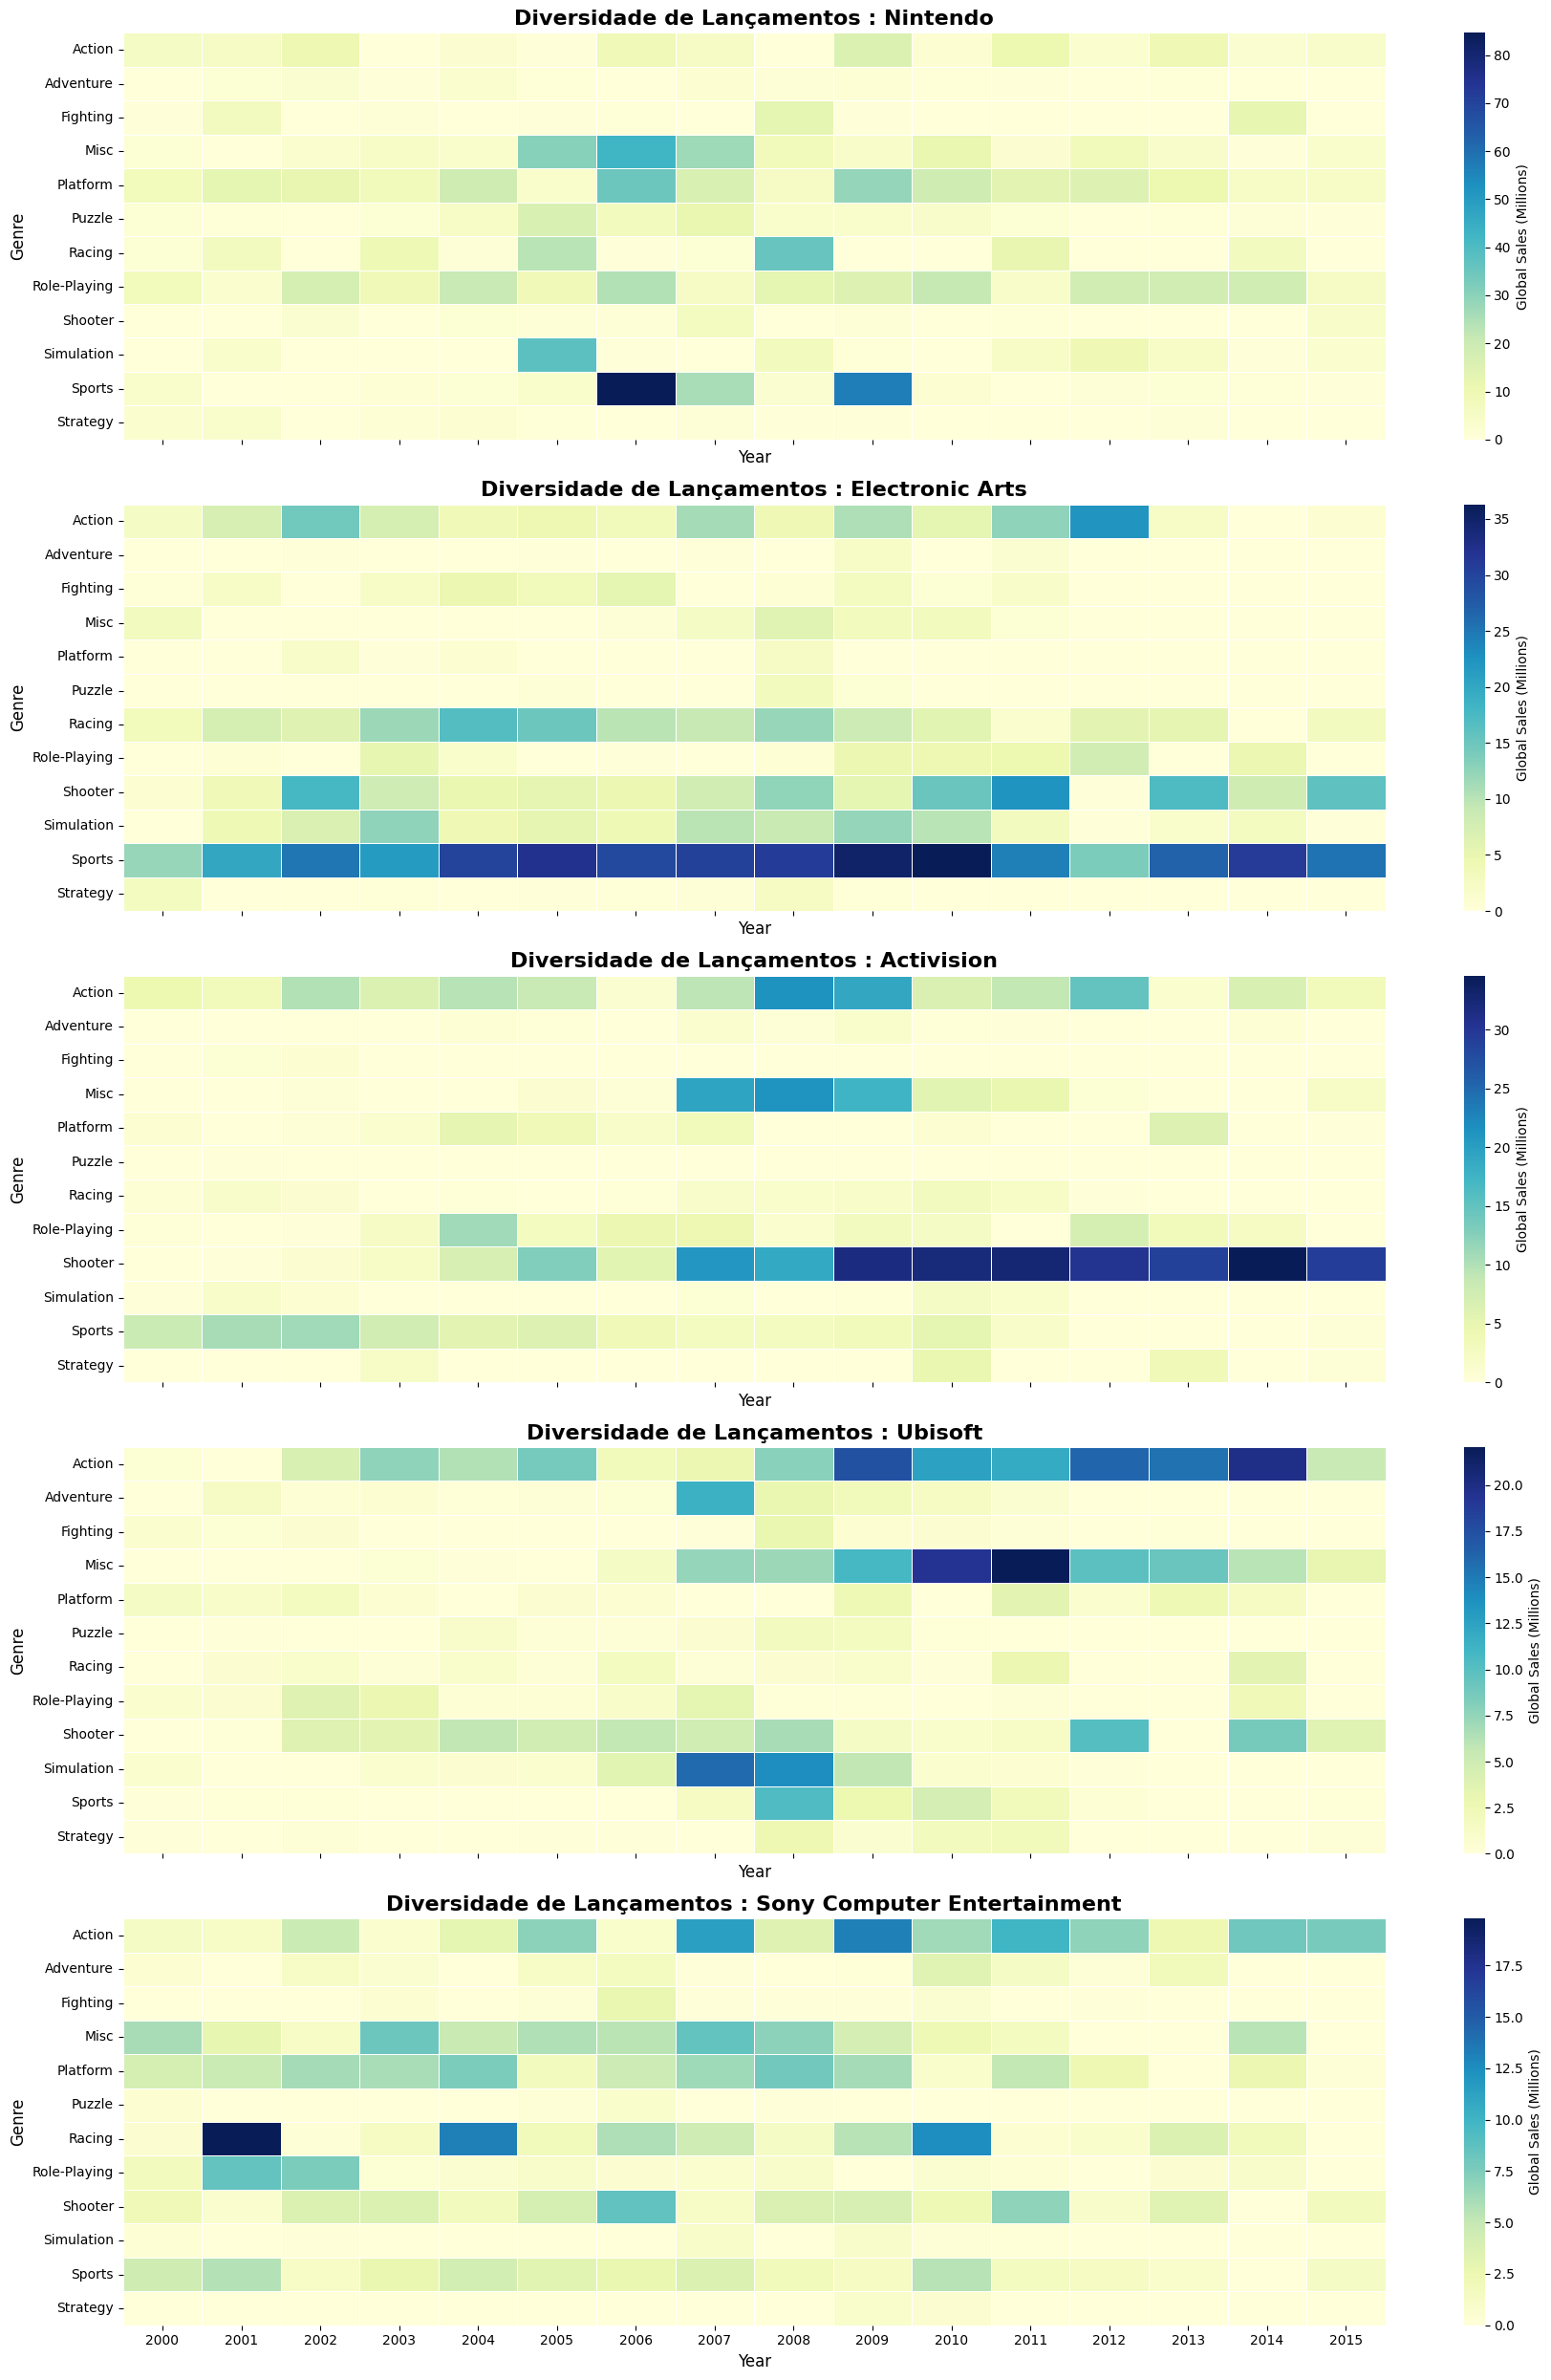

In [6]:
# 1. Load and clean the data
df = pd.read_csv('datasetCompVis.csv')
df = df[(df['Year'] >= 2000) & (df['Year'] <= 2015)]
df = df.dropna(subset=['Year', 'Publisher']) # Remove rows with missing
# years/publishers
df['Year'] = df['Year'].astype(int)

# 2. Identify the Top 5 Publishers by Total Global Sales
top_publishers = df.groupby('Publisher')['Global_Sales'].sum().nlargest(5).index
df_top = df[df['Publisher'].isin(top_publishers)]

# 3. Create the visualization
# We use a loop to create a sub-heatmap for each publisher
fig, axes = plt.subplots(len(top_publishers), 1, figsize=(18, 5 * len(top_publishers)), sharex=True)

for i, pub in enumerate(top_publishers):
    # Prepare data for this publisher
    pub_data = df_top[df_top['Publisher'] == pub]

    # Pivot table: Rows = Genre, Columns = Year, Values = Sum of Global Sales
    pivot_table = pub_data.pivot_table(
        index='Genre',
        columns='Year',
        values='Global_Sales',
        aggfunc='sum'
    ).fillna(0) # Fill years/genres with no sales with 0

    # Plot the heatmap
    sns.heatmap(
        pivot_table,
        ax=axes[i],
        cmap='YlGnBu',
        cbar_kws={'label': 'Global Sales (Millions)'},
        linewidths=.5
    )

    axes[i].set_title(f'Diversidade de Lançamentos : {pub}', fontsize=16, fontweight='bold')
    axes[i].set_ylabel('Genre', fontsize=12)
    axes[i].set_xlabel('Year', fontsize=12)

plt.tight_layout()
plt.savefig('portfolio_heatmap.png')
plt.show()


/tmp/ipykernel_2726/1911109170.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_publishers_sales.values, y=top_publishers_sales.index, palette='viridis')


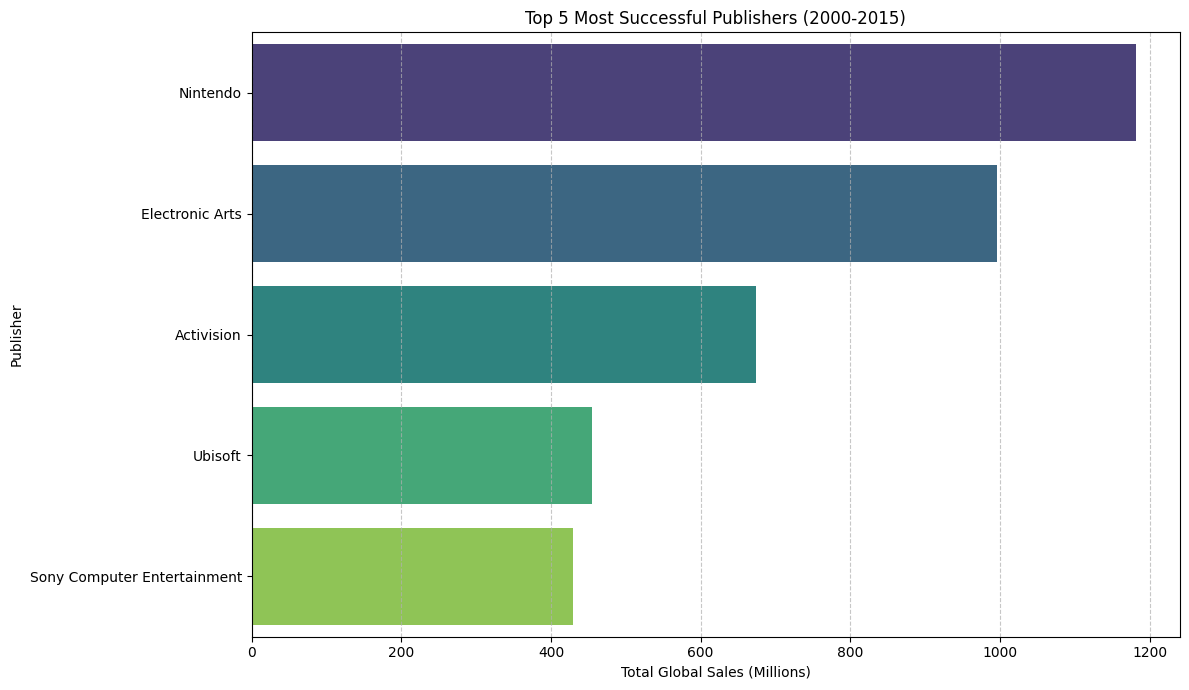

In [7]:
top_publishers_sales = df_top.groupby('Publisher')['Global_Sales'].sum().sort_values(ascending=False).head(5)

plt.figure(figsize=(12, 7))
sns.barplot(x=top_publishers_sales.values, y=top_publishers_sales.index, palette='viridis')
plt.title('Top 5 Most Successful Publishers (2000-2015)')
plt.xlabel('Total Global Sales (Millions)')
plt.ylabel('Publisher')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

/tmp/ipykernel_2726/3829690546.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_5_genres_sales.index, y=top_5_genres_sales.values, palette='plasma')


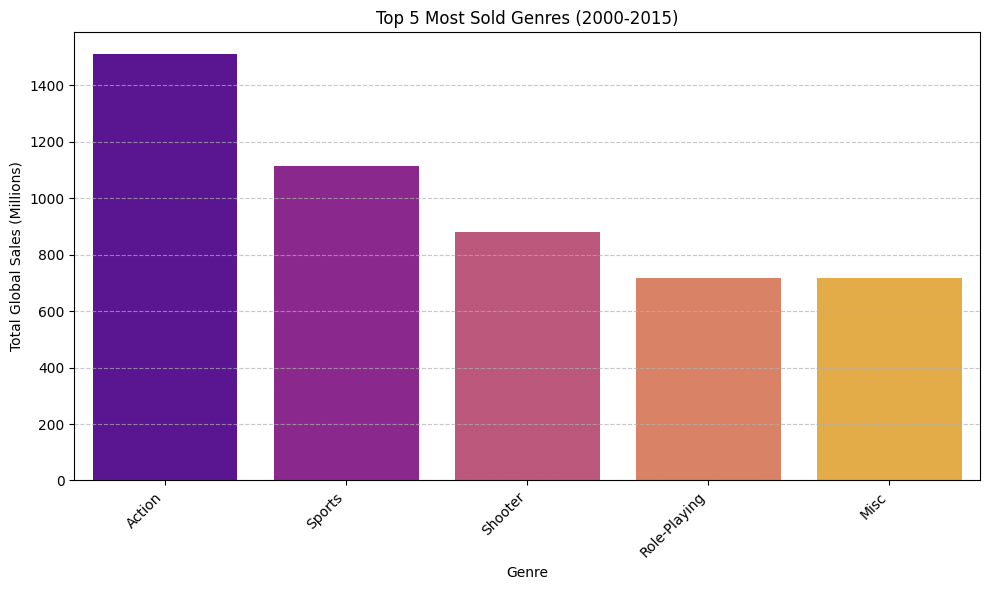

In [8]:
top_5_genres_sales = df.groupby('Genre')['Global_Sales'].sum().nlargest(5)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_5_genres_sales.index, y=top_5_genres_sales.values, palette='plasma')
plt.title('Top 5 Most Sold Genres (2000-2015)')
plt.xlabel('Genre')
plt.ylabel('Total Global Sales (Millions)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Sales Trend of Top Genres (2000-2015)

Let's visualize how the sales of the top 5 genres have evolved between 2000 and 2015. This can reveal trends in popularity and market shifts.

<Figure size 1400x800 with 0 Axes>

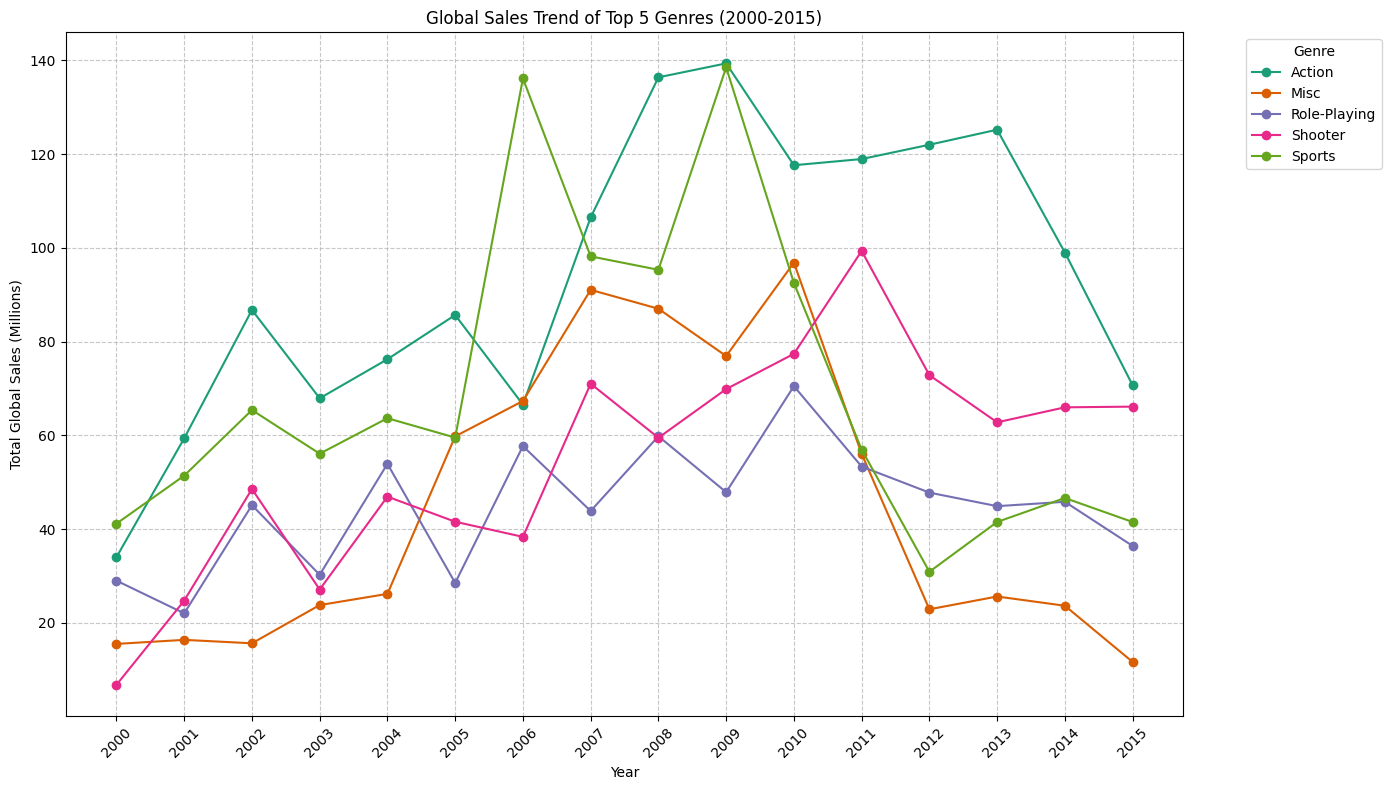

In [9]:
# Identify the top 5 genres based on total global sales in the 2000-2015 period
top_5_genres = df.groupby('Genre')['Global_Sales'].sum().nlargest(5).index

# Filter the DataFrame to include only these top 5 genres
df_top_genres_over_time = df[df['Genre'].isin(top_5_genres)]

# Group by Year and Genre, then sum the Global_Sales
genre_sales_by_year = df_top_genres_over_time.groupby(['Year', 'Genre'])['Global_Sales'].sum().unstack().fillna(0)

# Plot the sales trends for each of the top 5 genres
plt.figure(figsize=(14, 8))
genre_sales_by_year.plot(kind='line', marker='o', figsize=(14, 8), color=sns.color_palette('Dark2', len(top_5_genres)))
plt.title('Global Sales Trend of Top 5 Genres (2000-2015)')
plt.xlabel('Year')
plt.ylabel('Total Global Sales (Millions)')
plt.xticks(genre_sales_by_year.index.astype(int), rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Genre', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

/tmp/ipykernel_2726/818120916.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_publishers_sales.values, y=top_publishers_sales.index, palette='viridis', ax=ax_esquerdo_1)
/tmp/ipykernel_2726/818120916.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_genres_sales.index, y=top_10_genres_sales.values, palette='plasma', ax=ax_esquerdo_2)
/tmp/ipykernel_2726/818120916.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_esquerdo_2.set_xticklabels(top_10_genres_sales.index, rotation=45, ha='right') # Rotação das legendas


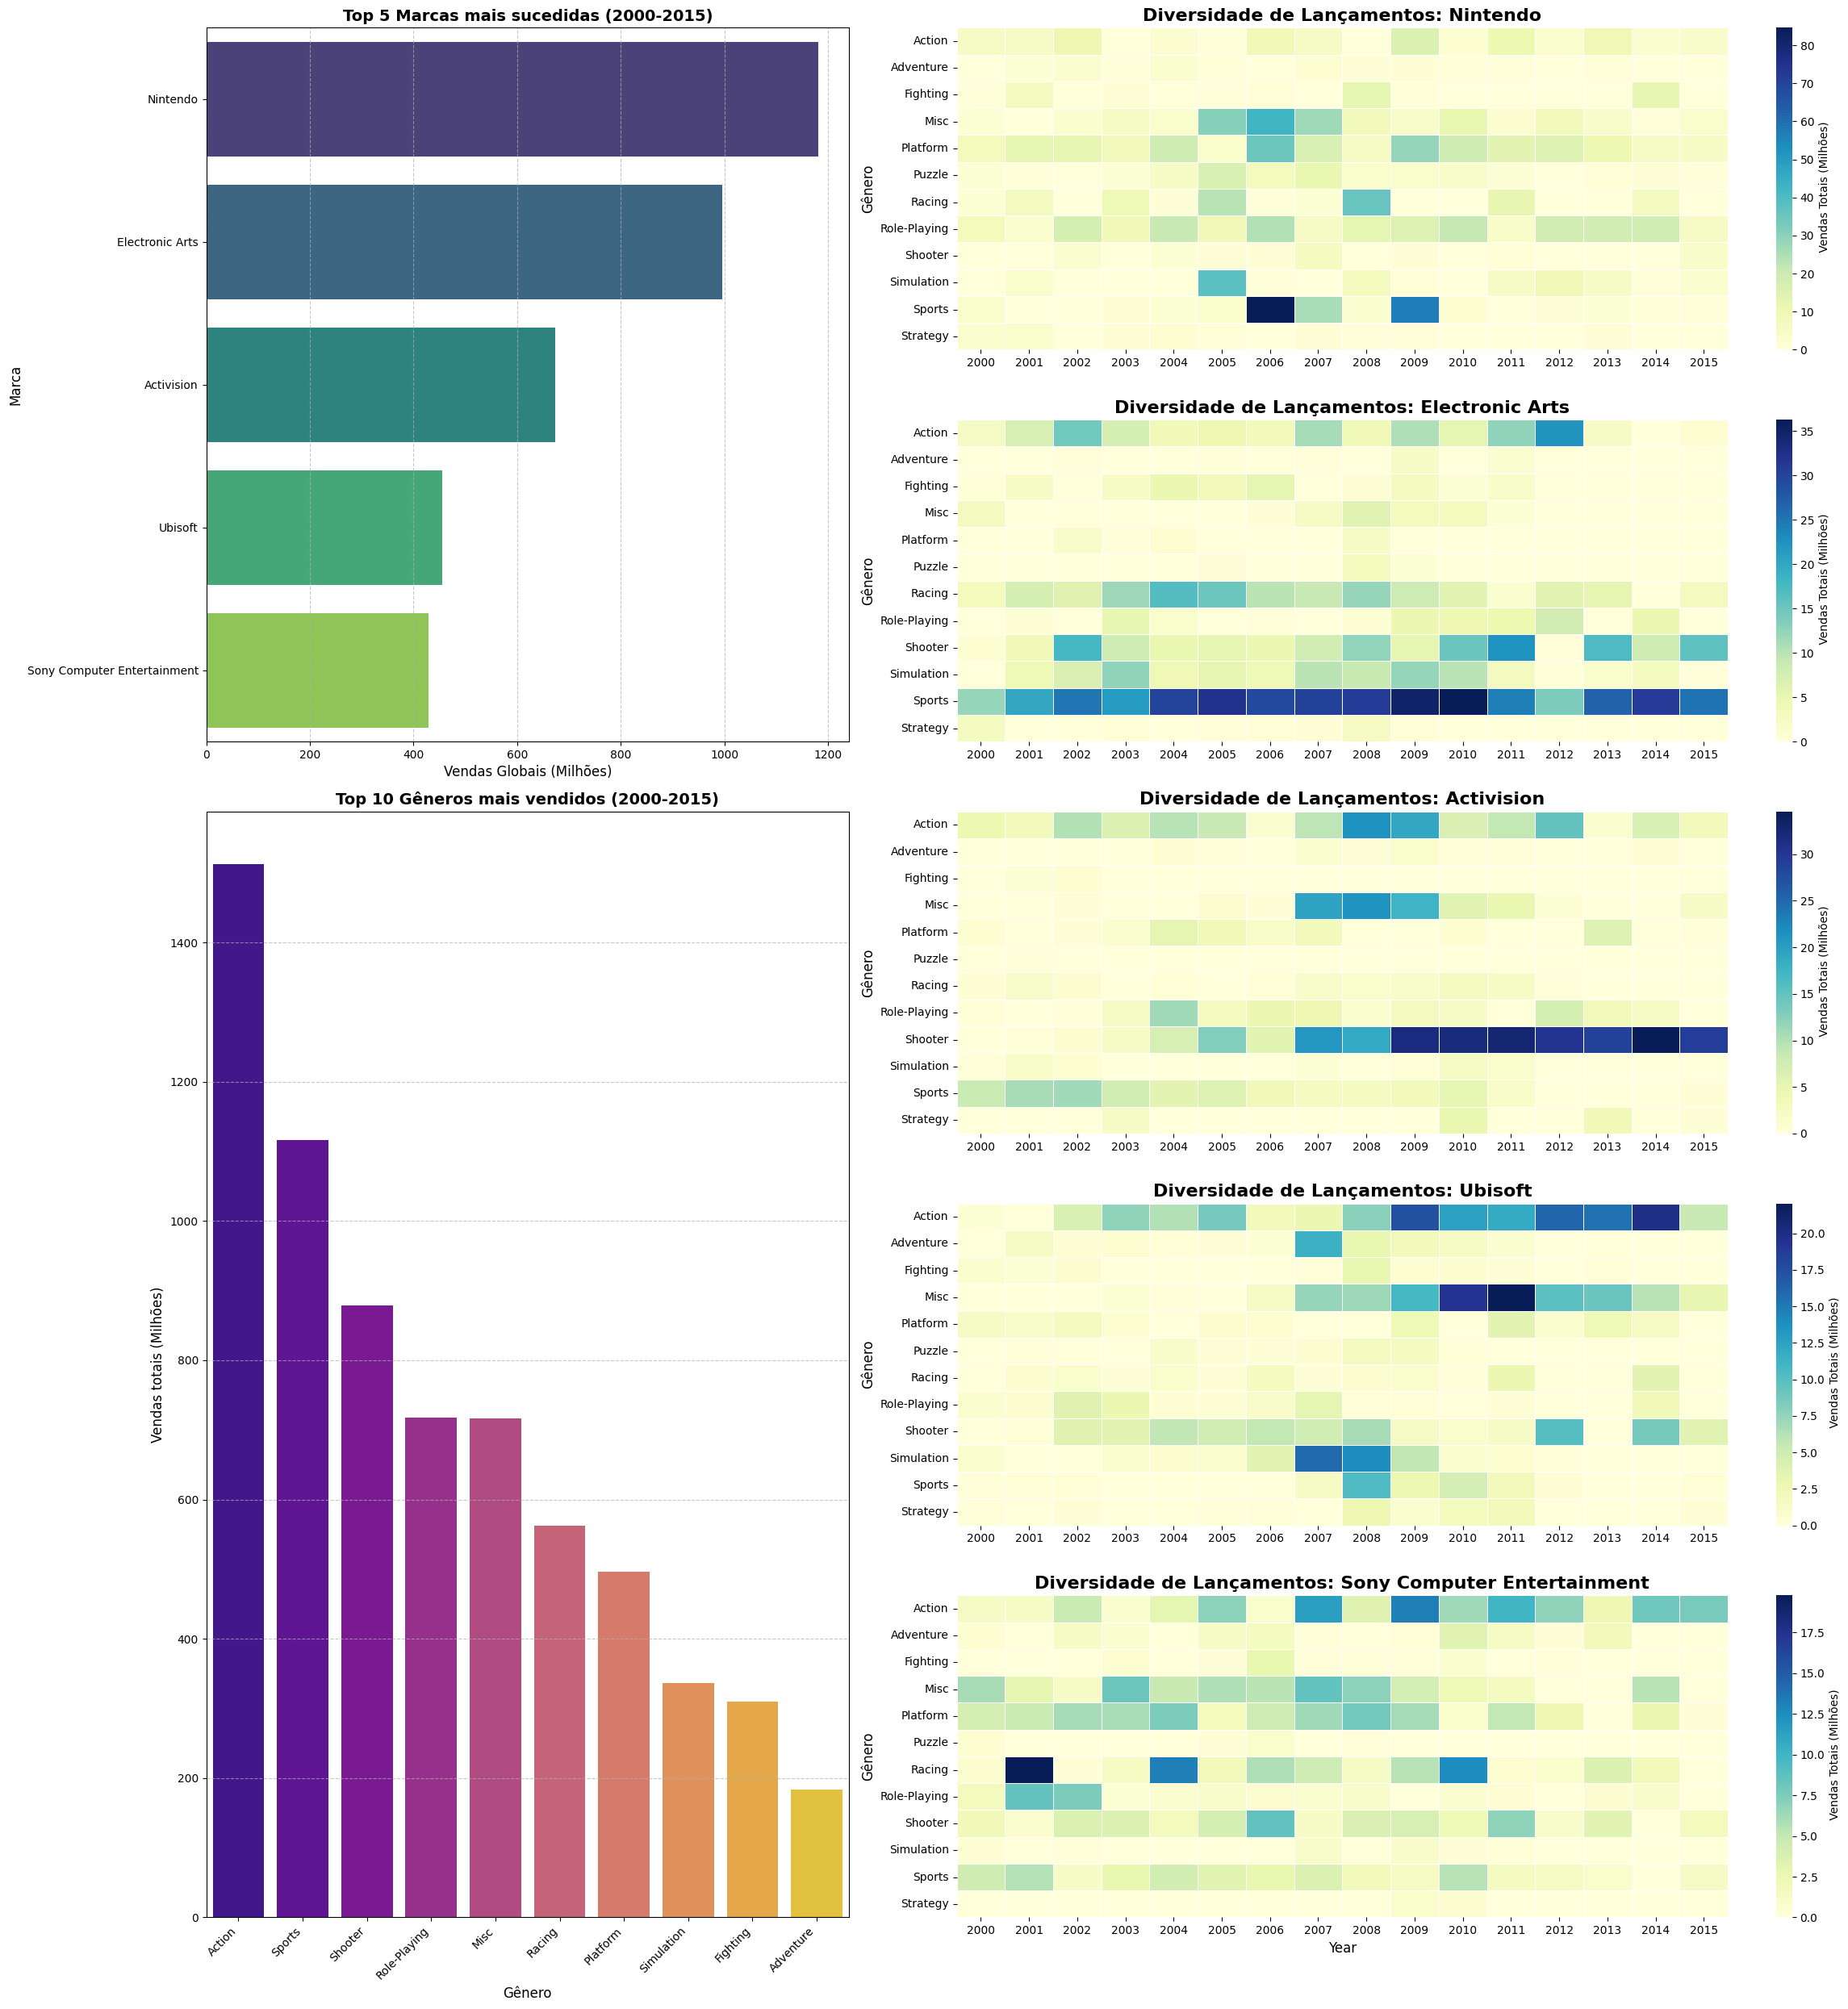

In [10]:

# 1. Carregar e limpar os dados (seu código original)
df = pd.read_csv('datasetCompVis.csv')
df = df[(df['Year'] >= 2000) & (df['Year'] <= 2015)]
df = df.dropna(subset=['Year', 'Publisher'])
df['Year'] = df['Year'].astype(int)

# 2. Preparar os dados para os gráficos
top_publishers = df.groupby('Publisher')['Global_Sales'].sum().nlargest(5).index
df_top = df[df['Publisher'].isin(top_publishers)]

# Seus agrupamentos originais
top_publishers_sales = df_top.groupby('Publisher')['Global_Sales'].sum().sort_values(ascending=False).head(5)
top_10_genres_sales = df.groupby('Genre')['Global_Sales'].sum().nlargest(10)

# ==========================================
# 3. CONFIGURAR A GRADE COM GRIDSPEC
# ==========================================
fig = plt.figure(figsize=(24, 5 * len(top_publishers)))

# Grade de 5 linhas por 2 colunas. Segunda coluna (heatmaps) é mais larga.
gs = fig.add_gridspec(nrows=len(top_publishers), ncols=2, width_ratios=[1, 1.5])

# ==========================================
# 4. SEUS GRAFICOS NA COLUNA DA ESQUERDA (Coluna 0)
# ==========================================

# --- Seu Gráfico 1: Top 5 Publishers ---
ax_esquerdo_1 = fig.add_subplot(gs[0:2, 0]) # Ocupa linhas 0 e 1
sns.barplot(x=top_publishers_sales.values, y=top_publishers_sales.index, palette='viridis', ax=ax_esquerdo_1)
ax_esquerdo_1.set_title('Top 5 Marcas mais sucedidas (2000-2015)', fontsize=14, fontweight='bold')
ax_esquerdo_1.set_xlabel('Vendas Globais (Milhões)', fontsize=12)
ax_esquerdo_1.set_ylabel('Marca', fontsize=12)
ax_esquerdo_1.grid(axis='x', linestyle='--', alpha=0.7)

# --- Seu Gráfico 2: Top 10 Genres ---
ax_esquerdo_2 = fig.add_subplot(gs[2:5, 0]) # Ocupa linhas 2, 3 e 4 para dar mais espaço
sns.barplot(x=top_10_genres_sales.index, y=top_10_genres_sales.values, palette='plasma', ax=ax_esquerdo_2)
ax_esquerdo_2.set_title('Top 10 Gêneros mais vendidos (2000-2015)', fontsize=14, fontweight='bold')
ax_esquerdo_2.set_xlabel('Gênero', fontsize=12)
ax_esquerdo_2.set_ylabel('Vendas totais (Milhões)', fontsize=12)
ax_esquerdo_2.set_xticklabels(top_10_genres_sales.index, rotation=45, ha='right') # Rotação das legendas
ax_esquerdo_2.grid(axis='y', linestyle='--', alpha=0.7)


# ==========================================
# 5. SEUS HEATMAPS NA COLUNA DA DIREITA (Coluna 1)
# ==========================================
for i, pub in enumerate(top_publishers):
    pub_data = df_top[df_top['Publisher'] == pub]

    pivot_table = pub_data.pivot_table(
        index='Genre',
        columns='Year',
        values='Global_Sales',
        aggfunc='sum'
    ).fillna(0)

    ax_heatmap = fig.add_subplot(gs[i, 1])

    sns.heatmap(
        pivot_table,
        ax=ax_heatmap,
        cmap='YlGnBu',
        cbar_kws={'label': ' Vendas Totais (Milhões)'},
        linewidths=.5
    )

    ax_heatmap.set_title(f'Diversidade de Lançamentos: {pub}', fontsize=16, fontweight='bold')
    ax_heatmap.set_ylabel('Gênero', fontsize=12)

    if i < len(top_publishers) - 1:
        ax_heatmap.set_xlabel('')
    else:
        ax_heatmap.set_xlabel('Year', fontsize=12)

# Finalização e salvamento
plt.tight_layout()
plt.savefig('dashboard_final.png')
plt.show()

/tmp/ipykernel_2726/3775808738.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_publishers_sales.values, y=top_publishers_sales.index, palette='viridis', ax=axes['grafico_pub'])


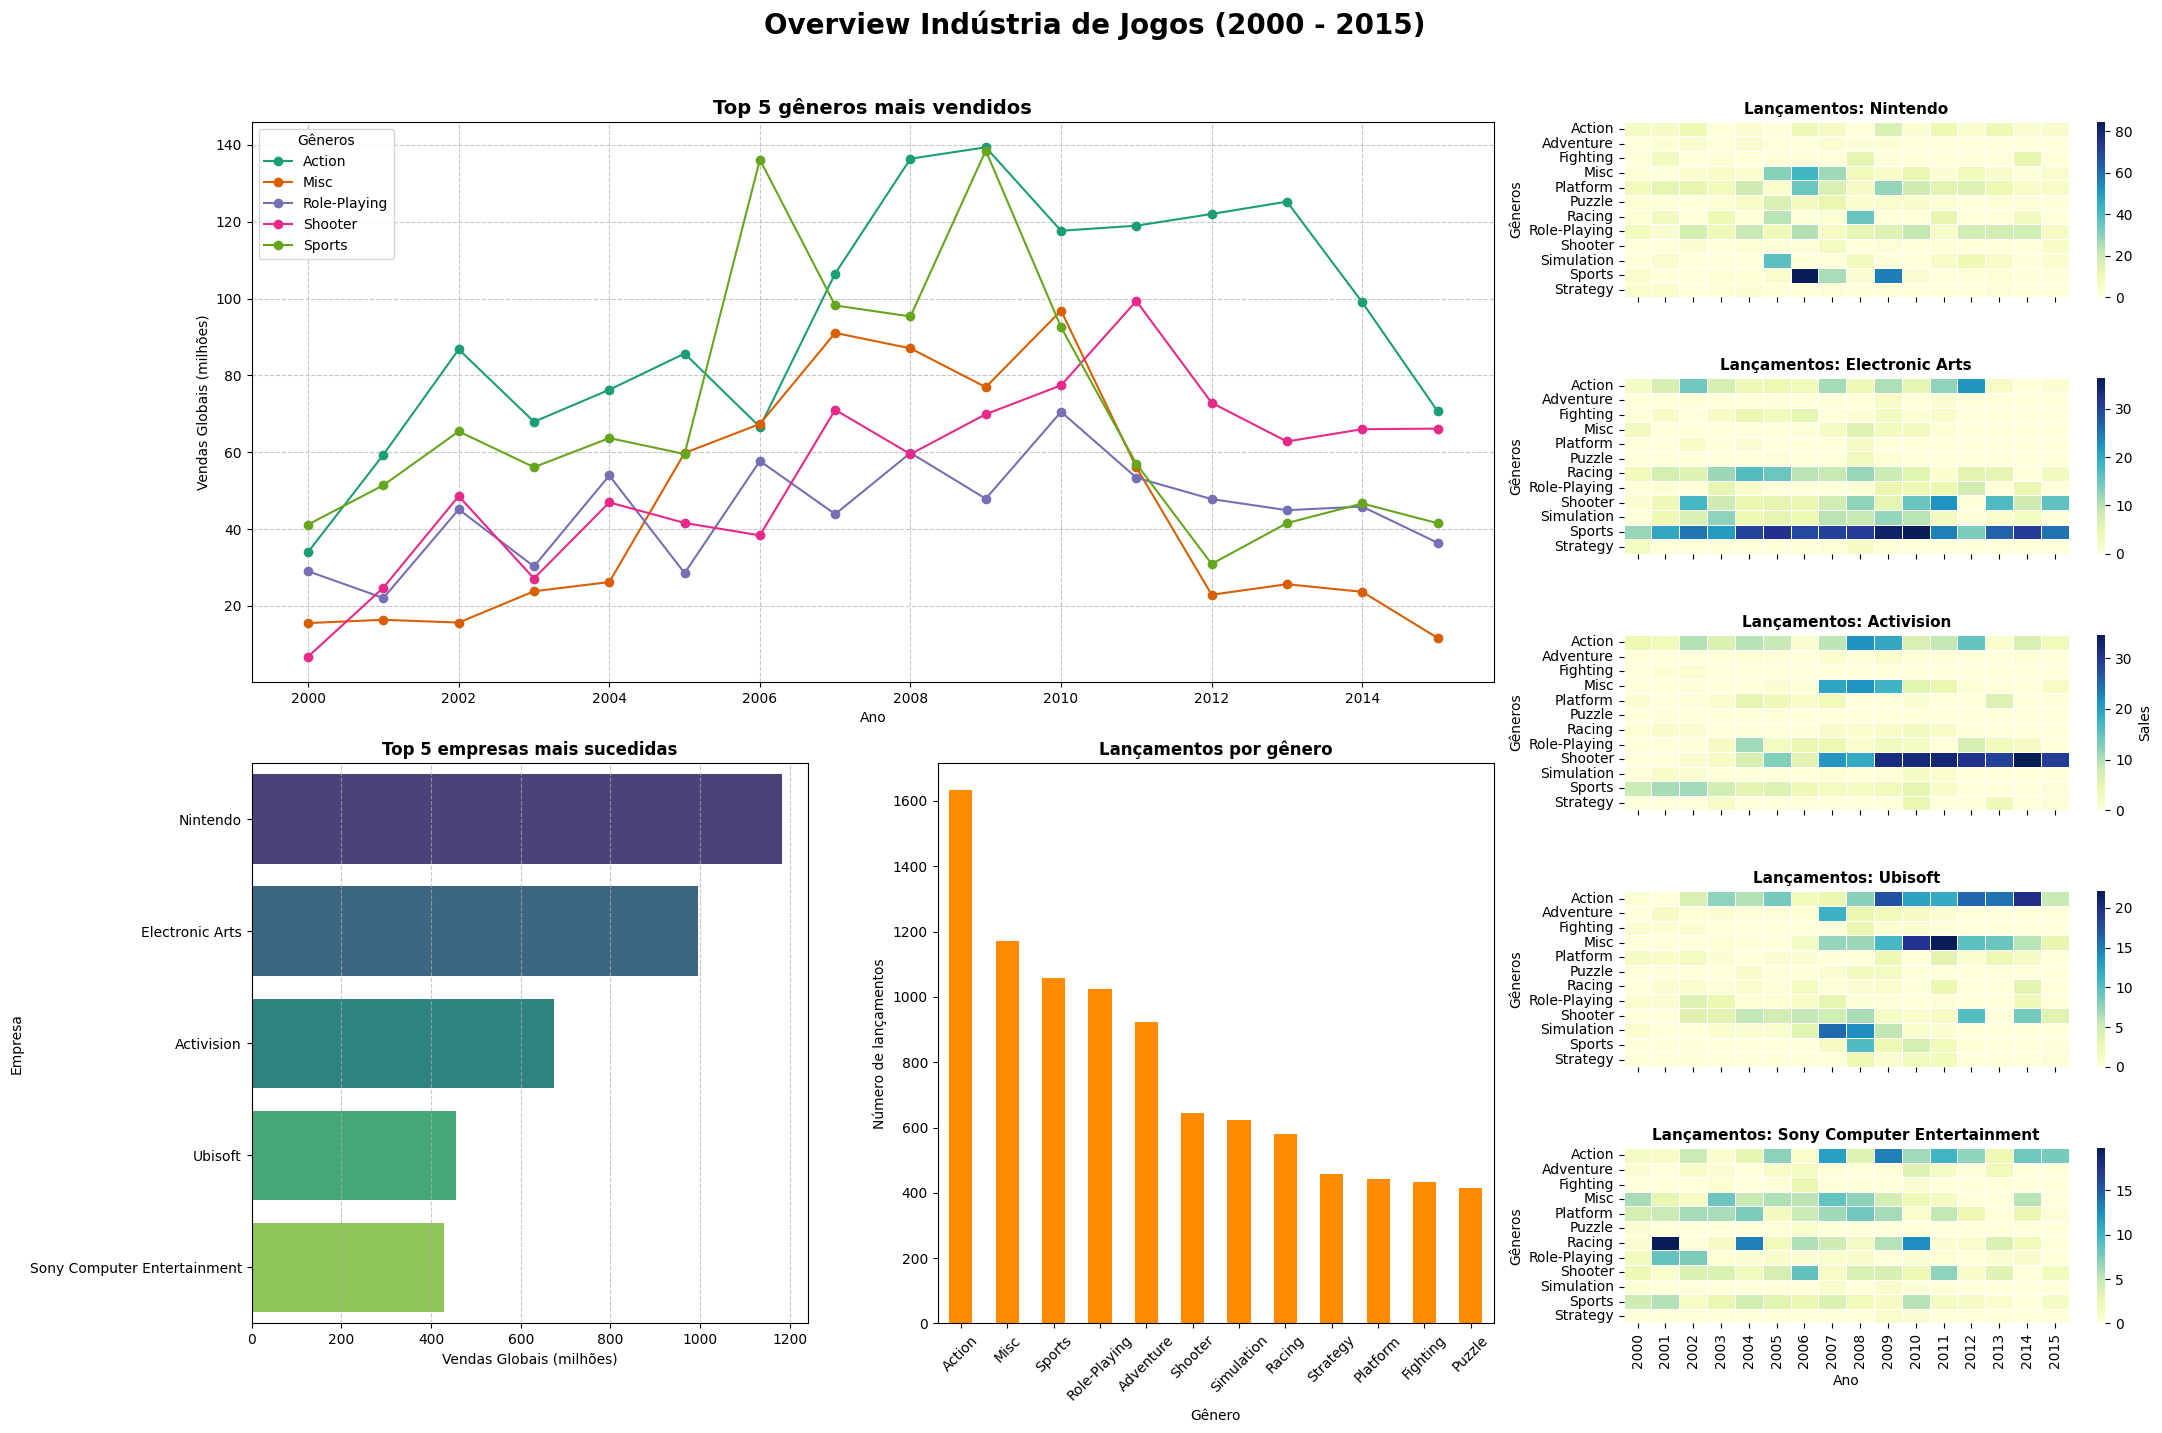

In [14]:
# ==========================================
# 1. CARREGAMENTO E PREPARAÇÃO GERAL DOS DADOS
# ==========================================
df = pd.read_csv('datasetCompVis.csv')
df = df[(df['Year'] >= 2000) & (df['Year'] <= 2015)]
df = df.dropna(subset=['Year', 'Publisher'])
df['Year'] = df['Year'].astype(int)

# Preparações para os gráficos
top_5_genres = df.groupby('Genre')['Global_Sales'].sum().nlargest(5).index
df_top_genres_over_time = df[df['Genre'].isin(top_5_genres)]
genre_sales_by_year = df_top_genres_over_time.groupby(['Year', 'Genre'])['Global_Sales'].sum().unstack().fillna(0)

top_publishers = df.groupby('Publisher')['Global_Sales'].sum().nlargest(5).index
df_top = df[df['Publisher'].isin(top_publishers)]
top_publishers_sales = df_top.groupby('Publisher')['Global_Sales'].sum().sort_values(ascending=False).head(5)

games_per_genre_2005_2011 = df.groupby('Genre')['Name'].nunique().sort_values(ascending=False)

# ==========================================
# 2. DEFINIÇÃO DO LAYOUT DO DASHBOARD
# ==========================================
# Usamos 10 linhas virtuais para conseguir acomodar 5 heatmaps perfeitamente na direita
layout = [
    ['grafico_linha', 'grafico_linha', 'heat_0'],
    ['grafico_linha', 'grafico_linha', 'heat_0'],
    ['grafico_linha', 'grafico_linha', 'heat_1'],
    ['grafico_linha', 'grafico_linha', 'heat_1'],
    ['grafico_linha', 'grafico_linha', 'heat_2'],
    ['grafico_pub',   'grafico_genre', 'heat_2'],
    ['grafico_pub',   'grafico_genre', 'heat_3'],
    ['grafico_pub',   'grafico_genre', 'heat_3'],
    ['grafico_pub',   'grafico_genre', 'heat_4'],
    ['grafico_pub',   'grafico_genre', 'heat_4'],
]

# Criando a figura gigante
fig, axes = plt.subplot_mosaic(layout, figsize=(22, 14))

# ==========================================
# 3. PLOTANDO OS GRÁFICOS
# ==========================================

# --- Gráfico: Linha 0, Colunas 0 e 1 (Ocupa a parte superior esquerda) ---
genre_sales_by_year.plot(kind='line', marker='o', ax=axes['grafico_linha'], color=sns.color_palette('Dark2', len(top_5_genres)))
axes['grafico_linha'].set_title('Top 5 gêneros mais vendidos', fontsize=14, fontweight='bold')
axes['grafico_linha'].set_xlabel('Ano')
axes['grafico_linha'].set_ylabel('Vendas Globais (milhões)')
axes['grafico_linha'].grid(True, linestyle='--', alpha=0.7)
axes['grafico_linha'].legend(title='Gêneros', loc='upper left')

# --- Gráfico: Linha 1, Coluna 0 (Canto inferior esquerdo) ---
sns.barplot(x=top_publishers_sales.values, y=top_publishers_sales.index, palette='viridis', ax=axes['grafico_pub'])
axes['grafico_pub'].set_title('Top 5 empresas mais sucedidas', fontsize=12, fontweight='bold')
axes['grafico_pub'].set_xlabel('Vendas Globais (milhões)')
axes['grafico_pub'].set_ylabel('Empresa')
axes['grafico_pub'].grid(axis='x', linestyle='--', alpha=0.7)

# --- Gráfico: Linha 1, Coluna 1 (Inferior meio) ---
games_per_genre_2005_2011.plot(kind='bar', color='darkorange', ax=axes['grafico_genre'])
axes['grafico_genre'].set_title('Lançamentos por gênero', fontsize=12, fontweight='bold')
axes['grafico_genre'].set_xlabel('Gênero')
axes['grafico_genre'].set_ylabel('Número de lançamentos')
axes['grafico_genre'].tick_params(axis='x', rotation=45)

# --- Gráfico: Coluna 2 inteira (Os 5 Heatmaps na direita) ---
for i, pub in enumerate(top_publishers):
    ax_heat = axes[f'heat_{i}']
    pub_data = df_top[df_top['Publisher'] == pub]
    pivot_table = pub_data.pivot_table(index='Genre', columns='Year', values='Global_Sales', aggfunc='sum').fillna(0)

    # Plota o heatmap no espaço correto ('heat_0', 'heat_1', etc)
    sns.heatmap(
        pivot_table,
        ax=ax_heat,
        cmap='YlGnBu',
        cbar_kws={'label': 'Sales' if i == 2 else ''}, # Coloca a legenda de cor só no gráfico do meio para ficar limpo
        linewidths=.5
    )

    ax_heat.set_title(f'Lançamentos: {pub}', fontsize=11, fontweight='bold')
    ax_heat.set_ylabel('Gêneros')

    # Só mostra o eixo X (Ano) no último heatmap de baixo para economizar espaço
    if i == 4:
        ax_heat.set_xlabel('Ano')
    else:
        ax_heat.set_xlabel('')
        ax_heat.tick_params(labelbottom=False)

# ==========================================
# 4. AJUSTES FINAIS
# ==========================================
fig.suptitle('Overview Indústria de Jogos (2000 - 2015)', fontsize=20, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('dashboard_completo.png', bbox_inches='tight', dpi=300)
plt.show()